In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import Rbf
import pickle

In [2]:
internal_data_analysis_dir = os.path.dirname(os.path.abspath('data_analysis.ipynb'))
root_dir = os.path.abspath(os.path.join(internal_data_analysis_dir, '..'))
internal_data_collection_dir = os.path.abspath(os.path.join(root_dir, '1_Data_Collection'))
print(f'The directory of data analysis : {internal_data_analysis_dir}')
print(f'The root directory of this project : {root_dir}')
print(f'The directory of data collection : {internal_data_collection_dir}')

The directory of data analysis : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis
The root directory of this project : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control
The directory of data collection : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection


In [3]:
data_file_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'New_New_New_Data_CSV'))
test_data_file_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'test_Data_CSV'))

In [4]:
for file in os.listdir(data_file_dir):
    print(os.path.join(data_file_dir, file))    

d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection\New_New_New_Data_CSV\1_one_volt.csv
d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection\New_New_New_Data_CSV\2_one_point_five_volt.csv
d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection\New_New_New_Data_CSV\3_two_volt.csv
d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection\New_New_New_Data_CSV\4_two_point_five_volt.csv
d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection\New_New_New_Data_CSV\5_three_volt.csv
d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection\New_New_New_Data_CSV\6_three_point_five_volt.csv


In [5]:
for file in os.listdir(test_data_file_dir):
    print(os.path.join(test_data_file_dir, file))    

d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\1_Data_Collection\test_Data_CSV\1_manual.csv


In [6]:
data_list = []
for i in range(len(os.listdir(data_file_dir))):
    data_list.append(pd.read_csv(os.path.join(data_file_dir, os.listdir(data_file_dir)[i])))

In [7]:
test_data_list = []
for i in range(len(os.listdir(test_data_file_dir))):
    test_data_list.append(pd.read_csv(os.path.join(test_data_file_dir, os.listdir(test_data_file_dir)[i])))

In [8]:
data_list[-1].head()

,Time,Inputs | Throttle Command,Inputs | Mapped Throttle,Inputs | Throttle Pot,Motor | Motor RPM,Vehicle | Vehicle Speed,Vehicle | Vehicle Acceleration,Vehicle | Time Between Speeds,Vehicle | Braking Distance Captured
0,56:34.2,0.0,0.0,0.30,0,0.0,0.0,0.0,0
1,56:34.2,0.0,0.0,0.30,0,0.0,0.0,0.0,0
2,56:34.3,0.0,0.0,0.30,0,0.0,0.0,0.0,0
3,56:34.5,0.0,0.0,0.29,0,0.0,0.0,0.0,0
4,56:34.6,0.0,0.0,0.29,0,0.0,0.0,0.0,0


In [9]:
test_data_list[-1].head()

,Time,Inputs | Throttle Command,Inputs | Throttle Multiplier,Inputs | Mapped Throttle,Inputs | Throttle Pot,Inputs | PD Throttle,Outputs | Analog Out,Outputs | Driver 1 PWM,Outputs | Driver 2 PWM,Outputs | Driver 3 PWM,Outputs | Driver 4 PWM,Motor | Motor RPM,Vehicle | Vehicle Speed,Vehicle | Vehicle Odometer,Vehicle | Vehicle Acceleration,Vehicle | Time Between Speeds
0,29:14.3,23.1,100,23.1,1.23,0,0,24,0,0,0,360,3.2,638.4,0.000,0.0
1,29:14.4,23.1,100,23.0,1.22,0,0,24,0,0,0,362,3.1,638.4,0.000,0.0
2,29:14.6,22.9,100,22.9,1.22,0,0,24,0,0,0,371,3.6,638.4,0.057,0.0
3,29:14.8,20.5,100,17.0,0.87,0,0,24,0,0,0,382,3.3,638.4,0.000,0.0
4,29:14.9,16.6,100,16.6,0.87,0,0,24,0,0,0,385,3.3,638.4,0.039,0.0


In [10]:
heads = list(data_list[0].columns)

In [11]:
print(heads)

['Time', 'Inputs | Throttle Command', 'Inputs | Mapped Throttle', 'Inputs | Throttle Pot', 'Motor | Motor RPM', 'Vehicle | Vehicle Speed', 'Vehicle | Vehicle Acceleration', 'Vehicle | Time Between Speeds', 'Vehicle | Braking Distance Captured']


In [12]:
def remove_duplicates(index, times, throttle_cmds, throttle_pots, motor_rpms, velocities, accelerations):
    
    times_in_seconds = []
    prev_min = None
    for ts in times:
        min, ss = ts.split(':')
        sec, milli = ss.split('.')
        if prev_min is None:
            prev_min = int(min)
        elif prev_min == 59 and int(min) < prev_min:
            min = int(min) + 60
        else:
            prev_min = int(min)
        times_in_seconds.append(int(min) * 60 + int(sec) + int(milli) / 10)
    times = [round(time - times_in_seconds[0], 1) for time in times_in_seconds] 
    
    unique_dict = dict()
    for key, *values in zip(times, throttle_cmds, throttle_pots, motor_rpms, velocities, accelerations):
        if key not in unique_dict:
            unique_dict[key] = values
    altered_data = []
    altered_data.append(list(unique_dict.keys()))
    value_list = list(zip(*unique_dict.values()))
    altered_data.extend(list(lst) for lst in value_list)
    altered_data[3] = [max(0.0, x) for x in altered_data[3]]
    altered_data[4] = [max(0.0, x) for x in altered_data[4]]
    return altered_data

In [13]:
altered_data_list = []
for i, data in enumerate(data_list):
    altered_data_list.append(remove_duplicates(i, list(data['Time']), list(data['Inputs | Throttle Command']), list(data['Inputs | Throttle Pot']), list(data['Motor | Motor RPM']), list(data['Vehicle | Vehicle Speed']), list(data['Vehicle | Vehicle Acceleration'])))

In [14]:
altered_test_data_list = []
for i, data in enumerate(test_data_list):
    altered_test_data_list.append(remove_duplicates(i, list(data['Time']), list(data['Inputs | Throttle Command']), list(data['Inputs | Throttle Pot']), list(data['Motor | Motor RPM']), list(data['Vehicle | Vehicle Speed']), list(data['Vehicle | Vehicle Acceleration'])))

In [15]:
store_brakepoints = []
store_delayed_brakepoints = []
seq_length = 20
for data in altered_data_list:
    start_test, start_coasting, end_coasting, flag = 0, 0, len(data[1]), 0
    counter = 0
    for i, tcmd in enumerate(data[1]):
        if flag == 0 and tcmd != 0:
            start_test, flag = i - 1, 1
        elif flag == 1 and tcmd == 0:
            start_coasting, flag = i - 1, 2
        elif flag == 2 and data[3][i] == 0:
            flag = 3
            counter += 1
        elif counter <= 5 and flag == 3:
            counter += 1
        elif counter > 5:
            end_coasting = i
            break
            
    store_brakepoints.append((start_test, start_coasting, end_coasting))
    store_delayed_brakepoints.append((max(start_test - seq_length + 1, 0), start_coasting - seq_length + 1, end_coasting))

In [16]:
print(store_brakepoints)
print(store_delayed_brakepoints)

[(69, 253, 310), (49, 189, 239), (53, 211, 271), (66, 235, 281), (72, 180, 235), (57, 195, 273)]
[(50, 234, 310), (30, 170, 239), (34, 192, 271), (47, 216, 281), (53, 161, 235), (38, 176, 273)]


In [17]:
def plot(data, brakepoints, title):
    tt, ct = data[0][brakepoints[0] : brakepoints[1] + 1], data[0][brakepoints[1] - 1 : brakepoints[2]]
    test_times, coast_times = [time - tt[0] for time in tt], [time - ct[0] for time in ct]
    plt.figure(figsize = (10, 20))    # (Width, height)
    
    ylabels = ['Throttle_cmd', 'Throttle_pot', 'Motor_rpm', 'Velocity (m/s)', 'Acceleration (m/s^2)']
    
    for i in range(len(data) - 1):
        plt.subplot(5, 2, 2 * i + 1)
        plt.plot(test_times, data[i + 1][brakepoints[0] : brakepoints[1] + 1])
        plt.ylabel(ylabels[i])
        plt.xlabel('Time (s)')
        plt.title(f'{title}_controlling')
        
        plt.subplot(5, 2, 2 * i + 2)
        plt.plot(coast_times, data[i + 1][brakepoints[1] - 1 : brakepoints[2]])
        plt.ylabel(ylabels[i])
        plt.xlabel('Time (s)')
        plt.title(f'{title}_coasting')
    plt.tight_layout()
    plt.show()    

In [18]:
def test_plot(data, title = 'manual'):
    tt = data[0]
    test_times = [time - tt[0] for time in tt]
    plt.figure(figsize = (5, 20))    # (Width, height)
    
    ylabels = ['Throttle_cmd', 'Throttle_pot', 'Motor_rpm', 'Velocity (m/s)', 'Acceleration (m/s^2)']
    
    for i in range(len(data) - 1):
        plt.subplot(5, 1, i + 1)
        plt.plot(test_times, data[i + 1])
        plt.ylabel(ylabels[i])
        plt.xlabel('Time (s)')
        plt.title(f'{title}_controlling')

    plt.tight_layout()
    plt.show()    

In [19]:
titles = ['1_volt', '1.5_volt', '2_volt', '2.5_volt', '3_volt', '3.5_volt']
#titles = ['1_volt', '2_volt_duplicate', '2_volt', '3_volt_duplicate_one', '3_volt', '3_volt_duplicate_two']

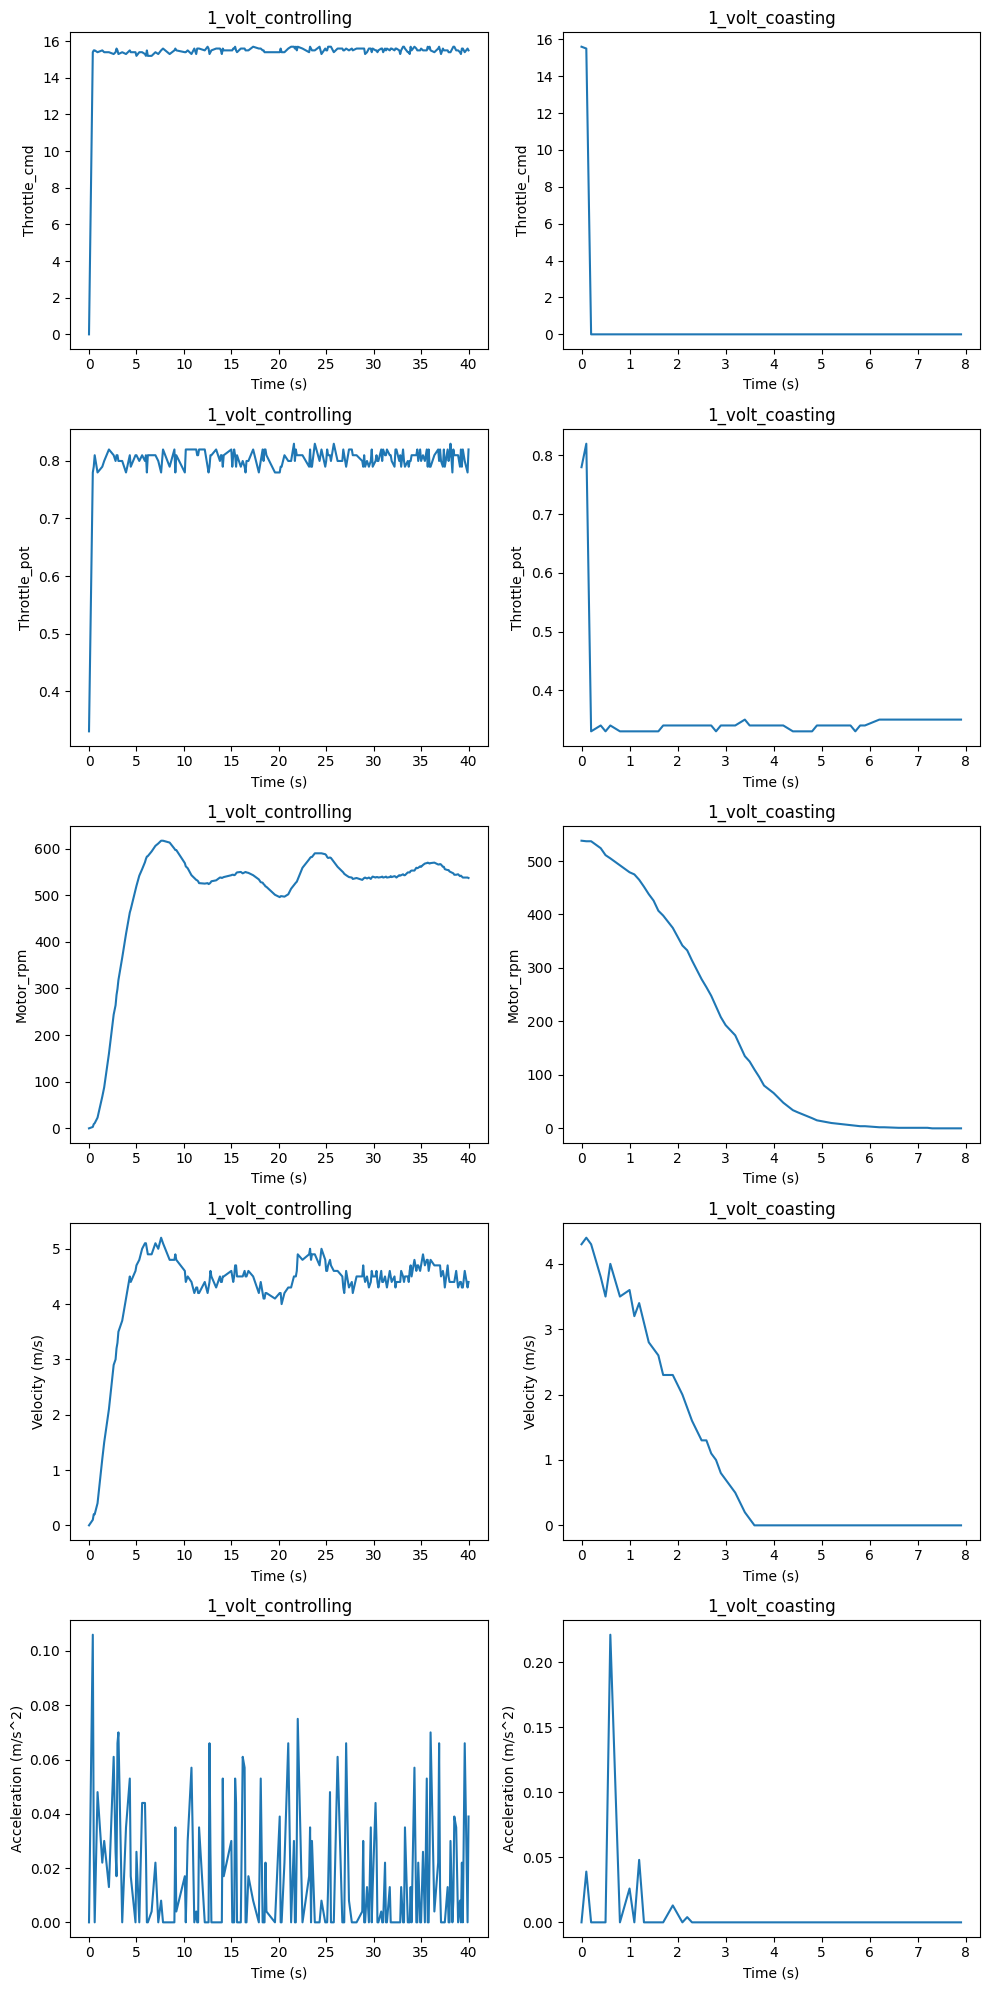

In [20]:
plot(altered_data_list[0], store_brakepoints[0], titles[0])

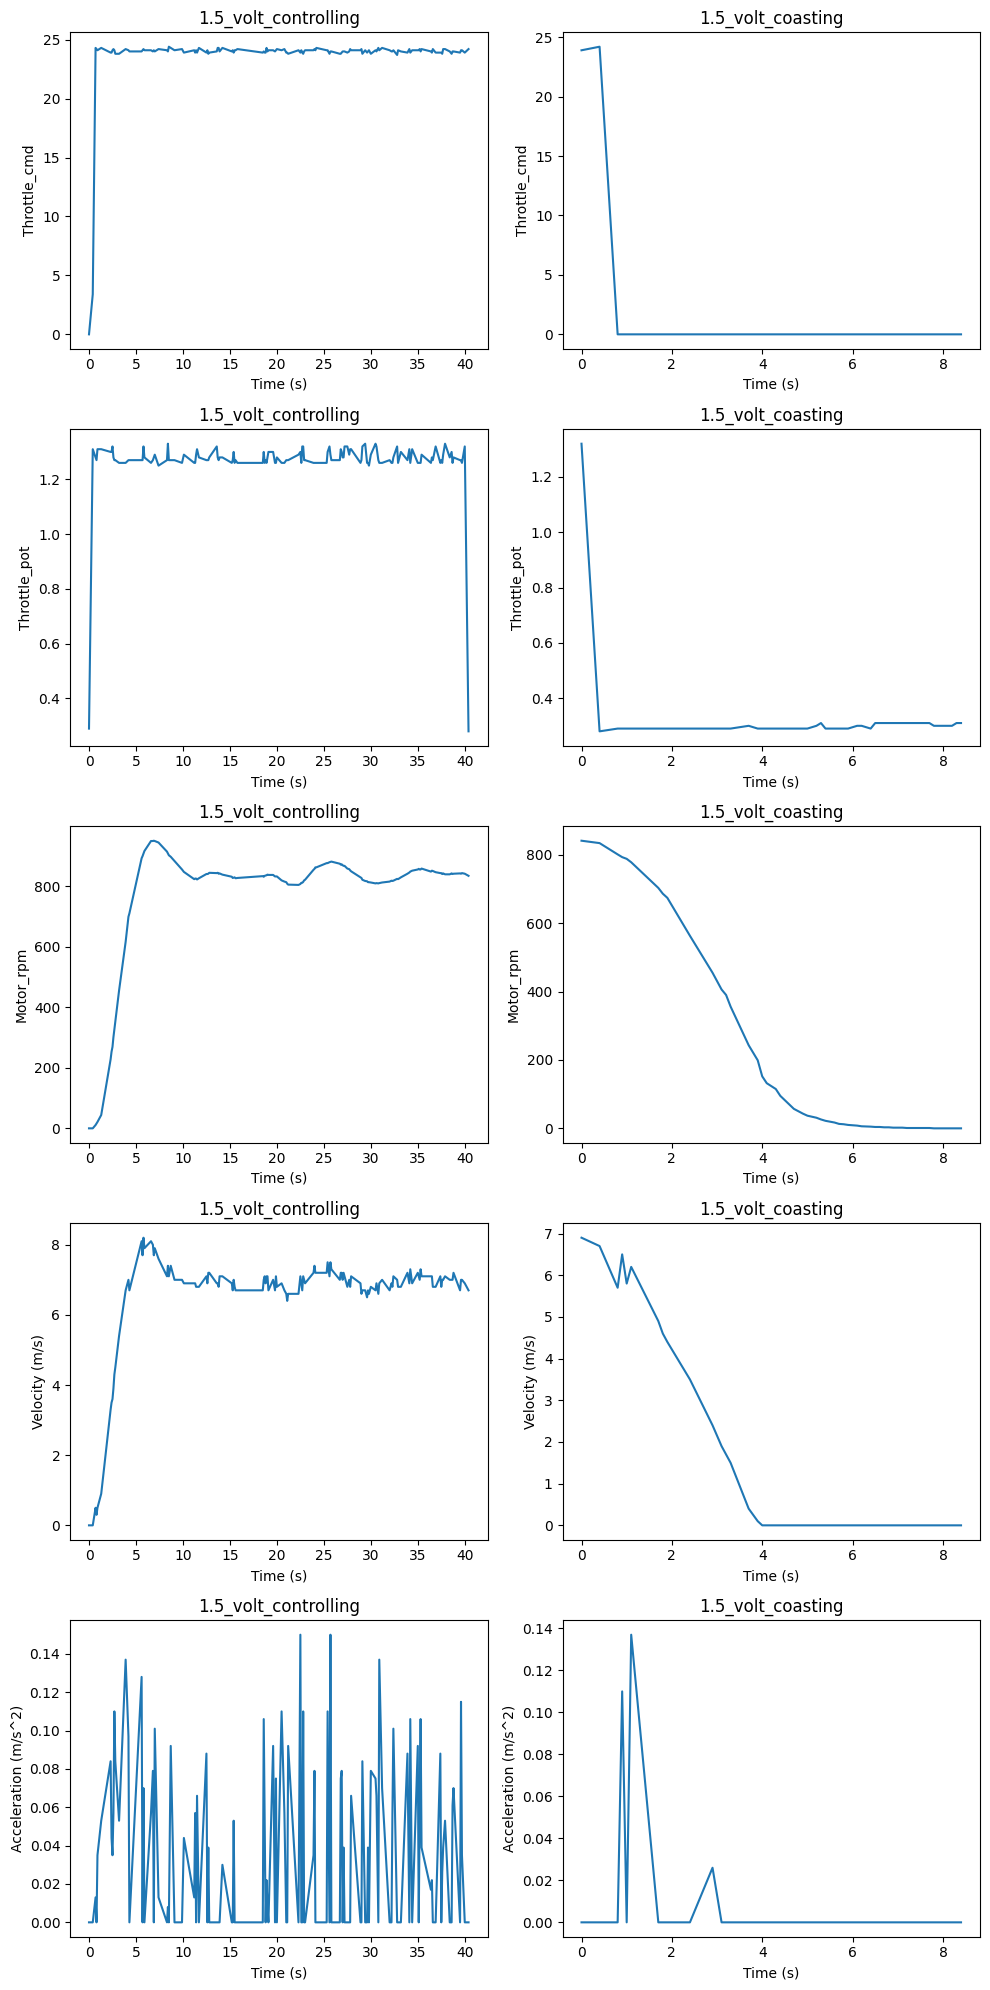

In [21]:
plot(altered_data_list[1], store_brakepoints[1], titles[1])

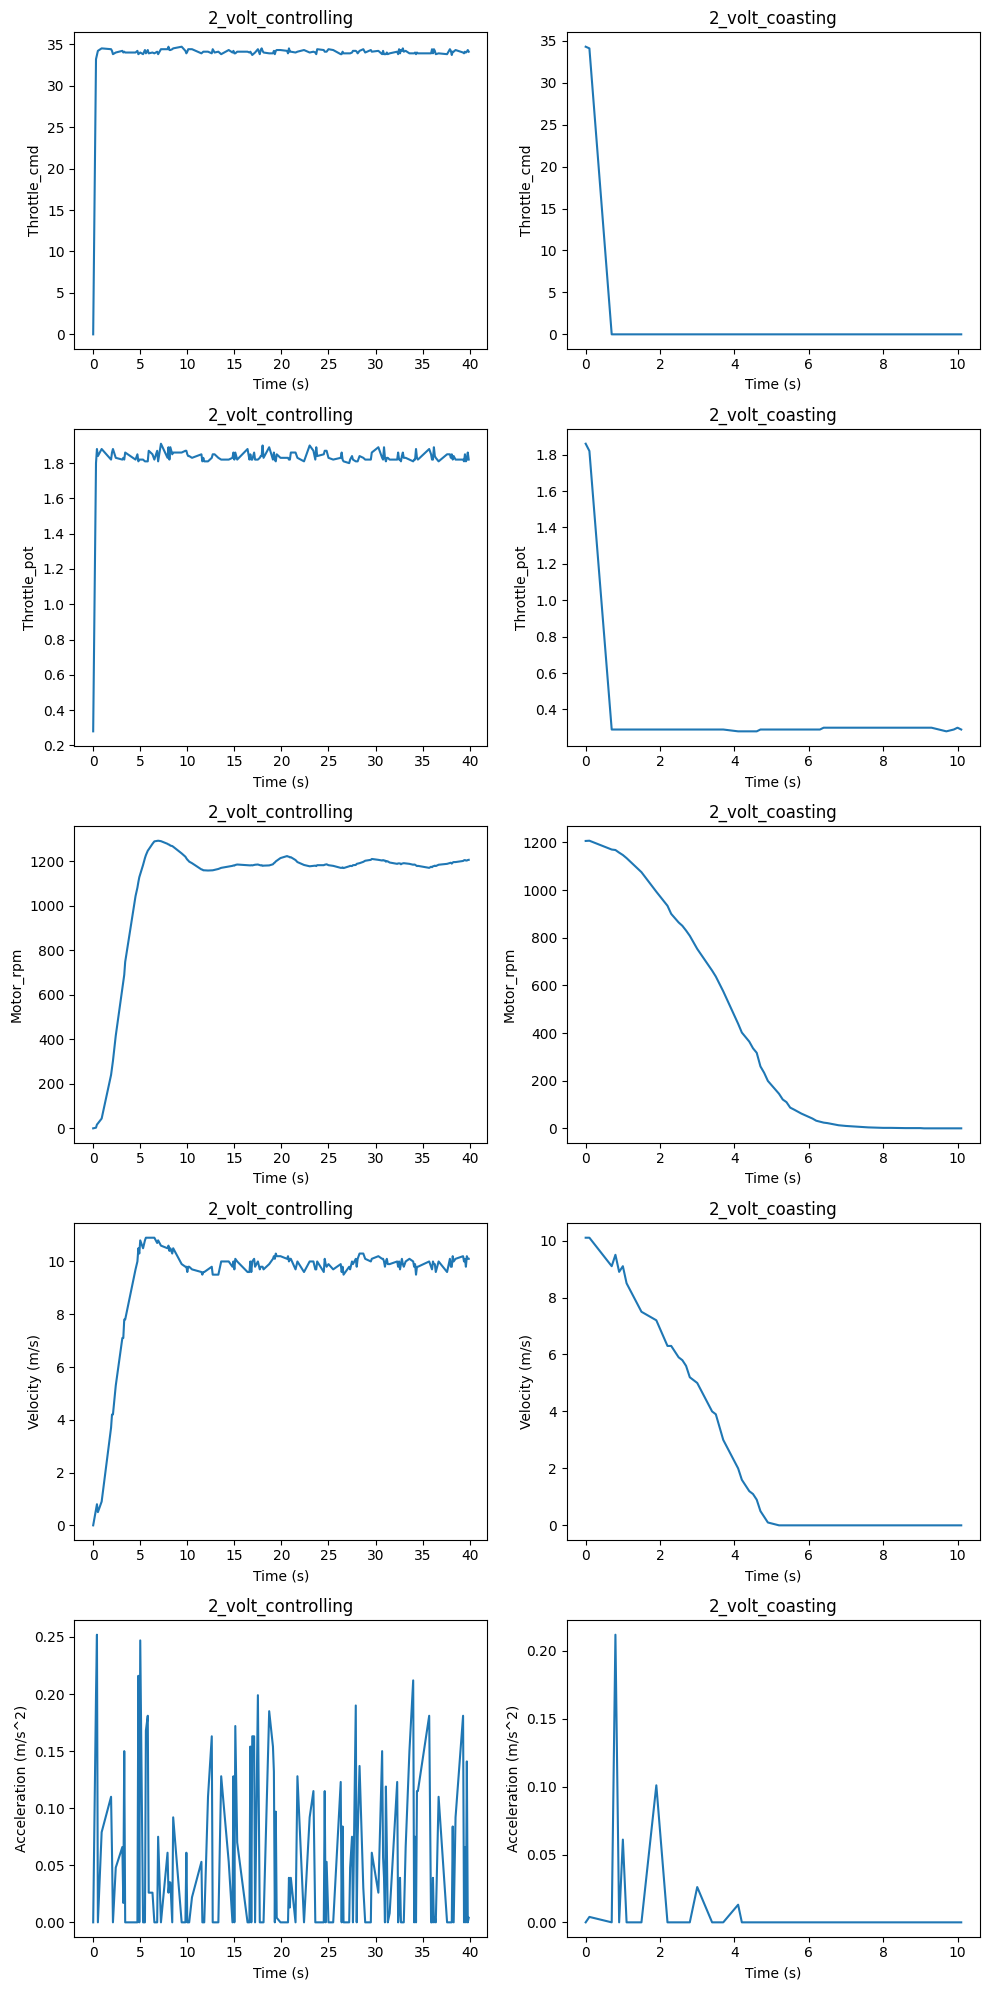

In [22]:
plot(altered_data_list[2], store_brakepoints[2], titles[2])

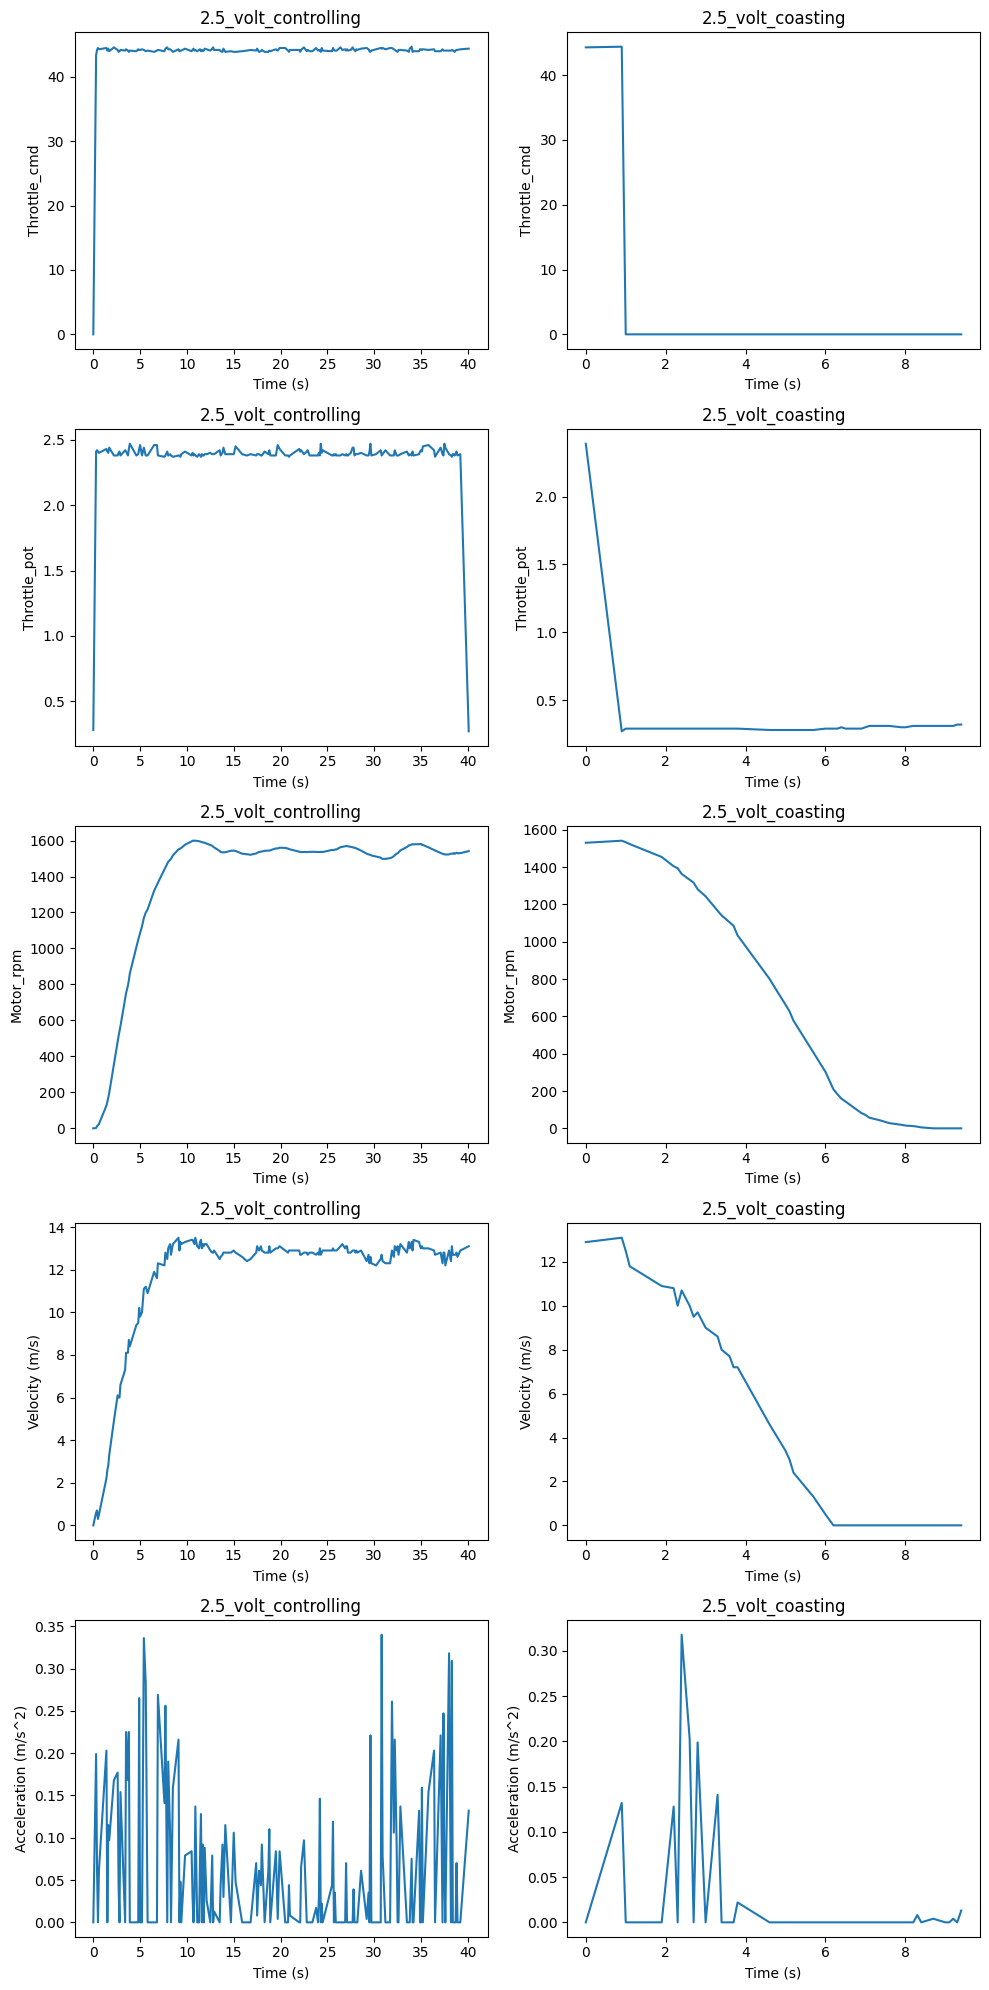

In [23]:
plot(altered_data_list[3], store_brakepoints[3], titles[3])

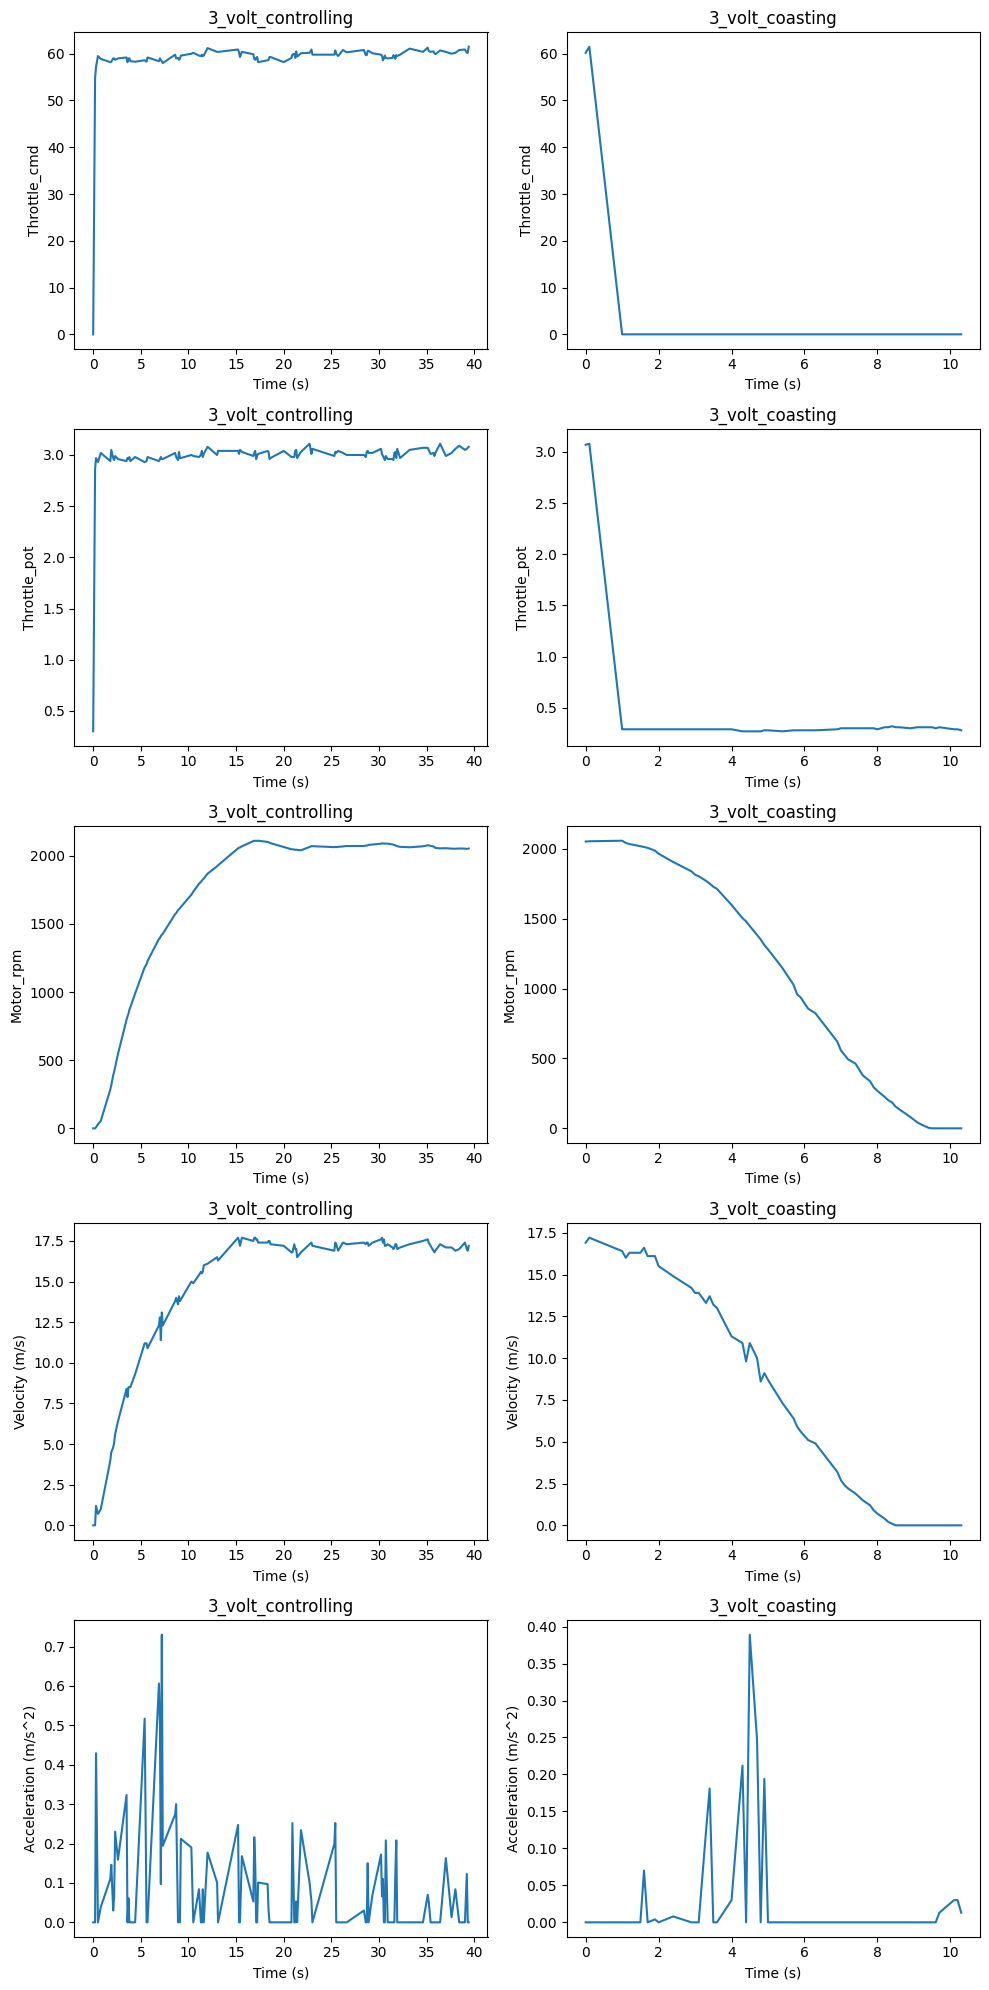

In [24]:
plot(altered_data_list[4], store_brakepoints[4], titles[4])

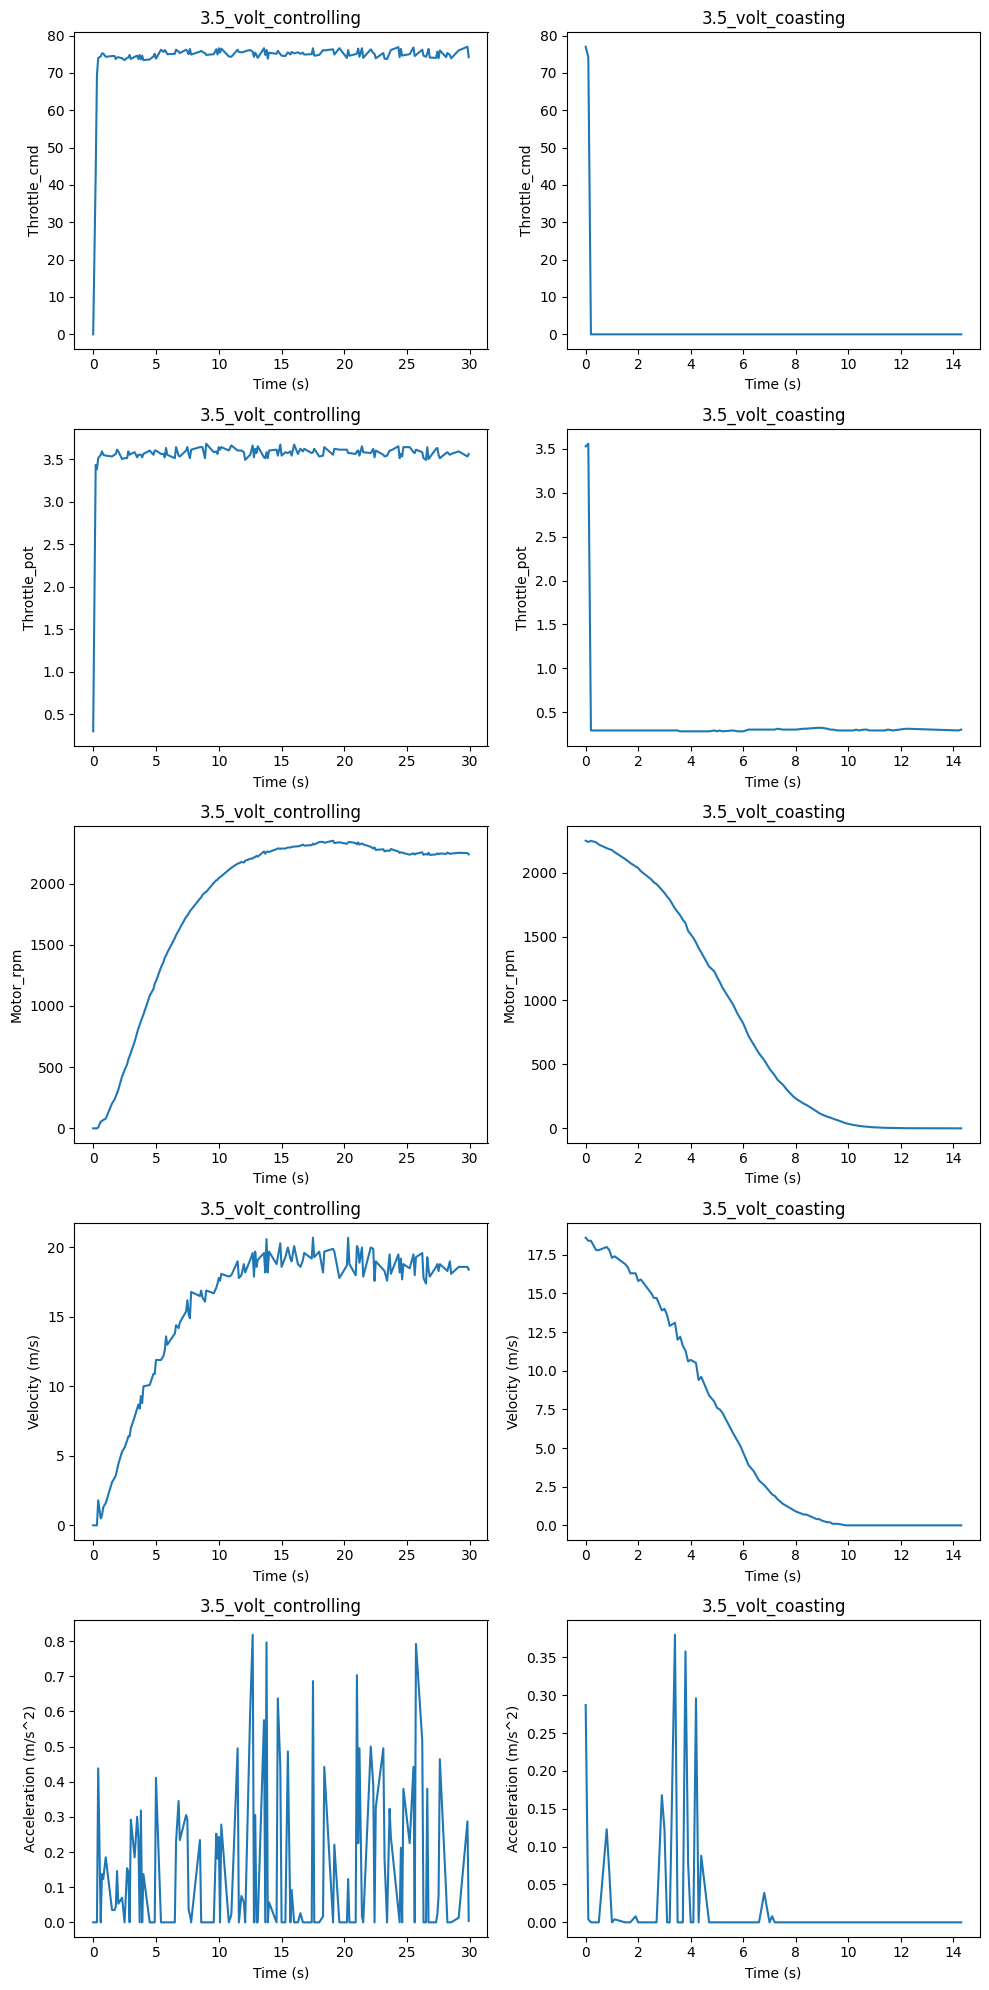

In [25]:
plot(altered_data_list[5], store_brakepoints[5], titles[5])

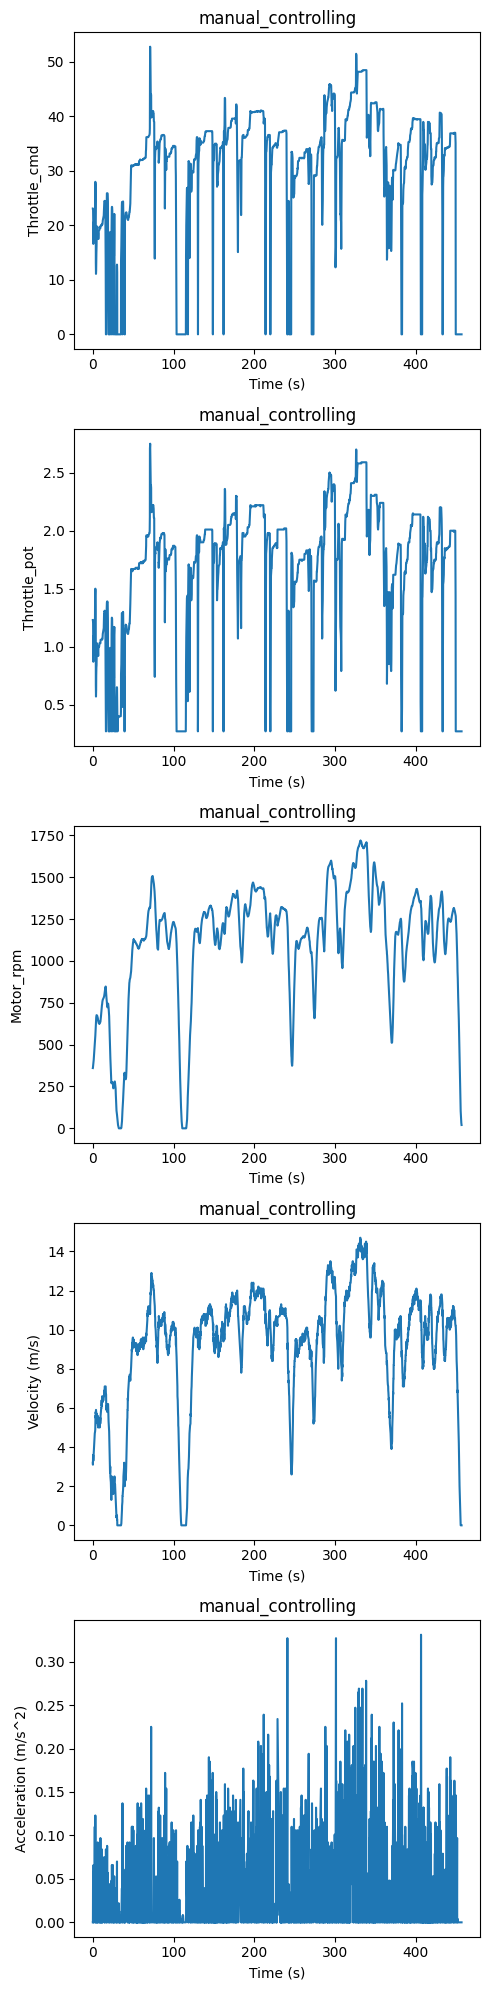

In [26]:
test_plot(altered_test_data_list[0])

#### Finding the throttle_pot, throttle_cmd, saturation_rpm, saturation_velocity mapping

In [27]:
#requested_throttle_pots = [0.0, 1.0, 1.15, 2.0, 2.5, 3.0, 4.5]
#requested_throttle_pots = [0.0, 1.0, 2.0, 2.0, 3.0, 3.0, 3.0]
requested_throttle_pots = [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
delivered_throttle_pots = [0.3]
delivered_throttle_cmds = [0.0]
mean_saturation_motor_rpms = [0.0]
mean_saturation_velocities = [0.0]
mean_saturation_rpm_to_speed_ratios = [119.67]

for i in range(len(altered_data_list)):
    print(f'The throttle input requested is : {requested_throttle_pots[i + 1]}')
    print(f'The throttle input delivered is : {float(round(np.mean(altered_data_list[i][2][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))}')
    delivered_throttle_pots.append(float(round(np.mean(altered_data_list[i][2][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)))
    print(f'The throttle command delivered is : {float(round(np.mean(altered_data_list[i][1][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))}')
    delivered_throttle_cmds.append(float(round(np.mean(altered_data_list[i][1][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)))
    print(f'The mean saturation motor rpm is : {float(round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))}')
    mean_saturation_motor_rpms.append(float(round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)))
    print(f'The mean saturation velocity is : {float(round(np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))}')
    mean_saturation_velocities.append(float(round(np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)))
    print(f'The mean saturation RPM to SPEED ratio is : {float(round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]) / np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))}')
    mean_saturation_rpm_to_speed_ratios.append(float(round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]) / np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)))
    print()

The throttle input requested is : 1.0
The throttle input delivered is : 0.81
The throttle command delivered is : 15.52
The mean saturation motor rpm is : 555.5
The mean saturation velocity is : 4.57
The mean saturation RPM to SPEED ratio is : 121.62

The throttle input requested is : 1.5
The throttle input delivered is : 1.28
The throttle command delivered is : 24.03
The mean saturation motor rpm is : 835.38
The mean saturation velocity is : 6.96
The mean saturation RPM to SPEED ratio is : 120.11

The throttle input requested is : 2.0
The throttle input delivered is : 1.83
The throttle command delivered is : 34.05
The mean saturation motor rpm is : 1190.0
The mean saturation velocity is : 9.92
The mean saturation RPM to SPEED ratio is : 119.93

The throttle input requested is : 2.5
The throttle input delivered is : 2.4
The throttle command delivered is : 44.19
The mean saturation motor rpm is : 1539.28
The mean saturation velocity is : 12.84
The mean saturation RPM to SPEED ratio is : 

In [28]:
manual_times = []
manual_motor_rpms = []
manual_throttle_cmds = []
manual_throttle_pots = []
manual_velocities = []

for i in range(len(altered_test_data_list)):
    manual_times.append(altered_test_data_list[i][0])
    manual_throttle_cmds.append(altered_test_data_list[i][1])
    manual_throttle_pots.append(altered_test_data_list[i][2])
    manual_motor_rpms.append(altered_test_data_list[i][3])
    manual_velocities.append(altered_test_data_list[i][4])

Text(0.5, 1.0, 'Delivered Throttle pots vs Requested Throttle pots')

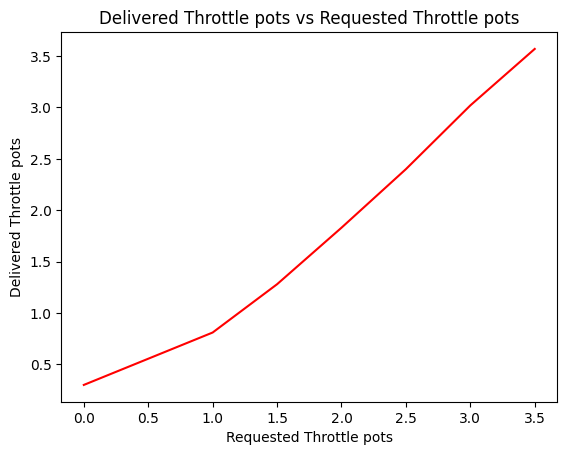

In [29]:
plt.plot(requested_throttle_pots, delivered_throttle_pots, color = 'red')
plt.xlabel('Requested Throttle pots')
plt.ylabel('Delivered Throttle pots')
plt.title('Delivered Throttle pots vs Requested Throttle pots')

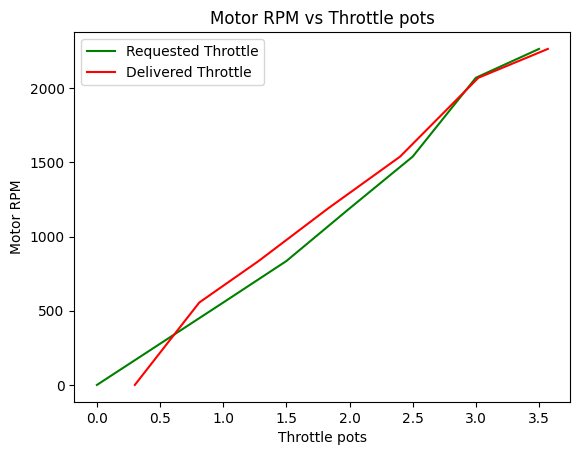

In [30]:
plt.plot(requested_throttle_pots, mean_saturation_motor_rpms, label = 'Requested Throttle', color = 'green')
plt.plot(delivered_throttle_pots, mean_saturation_motor_rpms, label = 'Delivered Throttle', color = 'red')
plt.xlabel('Throttle pots')
plt.ylabel('Motor RPM')
plt.title('Motor RPM vs Throttle pots')
plt.legend()

In [31]:
temp_requested_throttle_pots = [requested_throttle_pots[0], requested_throttle_pots[1], requested_throttle_pots[2], requested_throttle_pots[4]]
temp_delivered_throttle_pots = [delivered_throttle_pots[0], delivered_throttle_pots[1], delivered_throttle_pots[2], delivered_throttle_pots[4]]
temp_delivered_throttle_cmds = [delivered_throttle_cmds[0], delivered_throttle_cmds[1], delivered_throttle_cmds[2], delivered_throttle_cmds[4]]
temp_mean_saturation_motor_rpms = [mean_saturation_motor_rpms[0], mean_saturation_motor_rpms[1], mean_saturation_motor_rpms[2], mean_saturation_motor_rpms[4]]

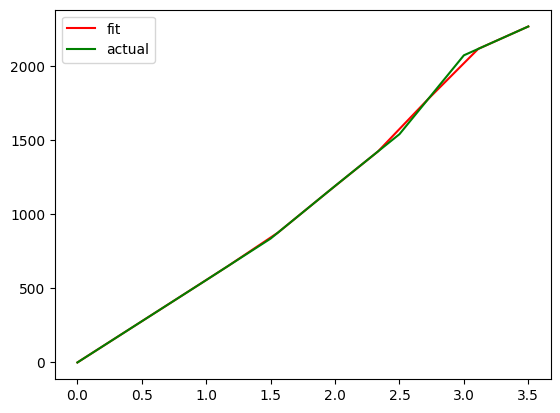

In [32]:
Rbf_interp = Rbf(requested_throttle_pots, mean_saturation_motor_rpms, function = 'linear') 
new_throttle_pots = np.linspace(requested_throttle_pots[0], requested_throttle_pots[-1], 10)
new_motor_rpms = Rbf_interp(new_throttle_pots)
plt.plot(new_throttle_pots, new_motor_rpms, label = 'fit', color = 'red')
plt.plot(requested_throttle_pots, mean_saturation_motor_rpms, label = 'actual', color = 'green')
plt.legend()
plt.show()

#### Storing the Rbf coefficients in a pickle file

In [33]:
file_path = os.path.join(internal_data_analysis_dir, 'rbf_model_throttle_pot_to_motor_rpm.pkl')
Rbf_data = {
    'x' : requested_throttle_pots,
    'y' : mean_saturation_motor_rpms,
    'function' : 'linear'
}
with open(file_path, 'wb') as f:
    pickle.dump(Rbf_data, f)

print(f"RBF Interpolator saved at : {file_path}")

RBF Interpolator saved at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis\rbf_model_throttle_pot_to_motor_rpm.pkl


#### Retrieving the Rbf coefficients from a pickle file

In [34]:
with open(file_path, 'rb') as f:
    Rbf_data = pickle.load(f)

print(f"RBF Interpolator loaded from : {file_path}")

RBF Interpolator loaded from : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis\rbf_model_throttle_pot_to_motor_rpm.pkl


#### Storing the brake points

In [35]:
file_path = os.path.join(internal_data_analysis_dir, 'data_brake_points.pkl')
with open(file_path, 'wb') as f:
    pickle.dump(store_brakepoints, f)

print(f"The brake points for data has been saved at : {file_path}")

The brake points for data has been saved at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis\data_brake_points.pkl


In [36]:
with open(file_path, 'rb') as f:
    store_brakepoints = pickle.load(f)

print(f"The brake points for data has been loaded from : {file_path}")
print(f"The brake points are : {store_brakepoints}")

The brake points for data has been loaded from : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis\data_brake_points.pkl
The brake points are : [(69, 253, 310), (49, 189, 239), (53, 211, 271), (66, 235, 281), (72, 180, 235), (57, 195, 273)]


In [37]:
file_path = os.path.join(internal_data_analysis_dir, 'data_delayed_brake_points.pkl')
with open(file_path, 'wb') as f:
    pickle.dump(store_delayed_brakepoints, f)

print(f"The delayed brake points for data has been saved at : {file_path}")

The delayed brake points for data has been saved at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis\data_delayed_brake_points.pkl


In [38]:
with open(file_path, 'rb') as f:
    store_delayed_brakepoints = pickle.load(f)

print(f"The delayed brake points for data has been loaded from : {file_path}")
print(f"The delayed brake points are : {store_delayed_brakepoints}")

The delayed brake points for data has been loaded from : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis\data_delayed_brake_points.pkl
The delayed brake points are : [(50, 234, 310), (30, 170, 239), (34, 192, 271), (47, 216, 281), (53, 161, 235), (38, 176, 273)]


#### Storing other data

In [39]:
requested_throttle_pots_file_path = os.path.join(internal_data_analysis_dir, 'requested_throtte_pots.pkl')
delivered_throttle_pots_file_path = os.path.join(internal_data_analysis_dir, 'delivered_throttle_pots.pkl')
delivered_throttle_cmds_file_path = os.path.join(internal_data_analysis_dir, 'delivered_throttle_cmds.pkl')
mean_saturation_motor_rpms_file_path = os.path.join(internal_data_analysis_dir, 'mean_saturated_motor_rpms.pkl')
with open(requested_throttle_pots_file_path, 'wb') as f:
    pickle.dump(requested_throttle_pots, f)
    
with open(delivered_throttle_pots_file_path, 'wb') as f:
    pickle.dump(delivered_throttle_pots, f)

with open(delivered_throttle_cmds_file_path, 'wb') as f:
    pickle.dump(delivered_throttle_cmds, f)
    
with open(mean_saturation_motor_rpms_file_path, 'wb') as f:
    pickle.dump(mean_saturation_motor_rpms, f)

print(f"The required data has been saved at : {internal_data_analysis_dir}")

The required data has been saved at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis


In [40]:
altered_data_list_file_path = os.path.join(internal_data_analysis_dir, 'data.pkl')
with open(altered_data_list_file_path, 'wb') as f:
    pickle.dump(altered_data_list, f)

print(f'The vehicle data has been stored at : {internal_data_analysis_dir}')

The vehicle data has been stored at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis


In [41]:
altered_test_data_list_file_path = os.path.join(internal_data_analysis_dir, 'manual_data.pkl')
with open(altered_test_data_list_file_path, 'wb') as f:
    pickle.dump(altered_test_data_list, f)

print(f'The vehicle data has been stored at : {internal_data_analysis_dir}')

The vehicle data has been stored at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis


#### Getting the relation between throttle command and motor rpm

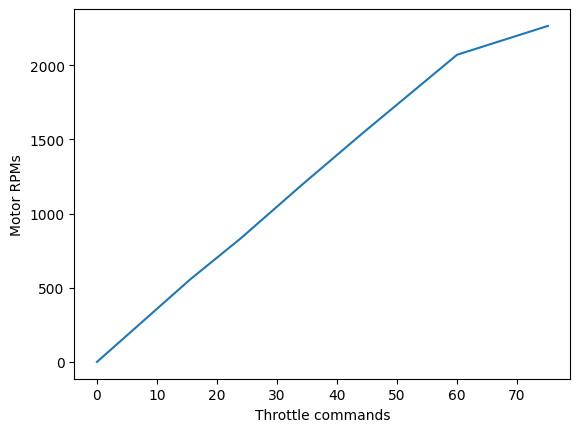

In [42]:
plt.plot(delivered_throttle_cmds, mean_saturation_motor_rpms)
plt.xlabel('Throttle commands')
plt.ylabel('Motor RPMs')
plt.show()

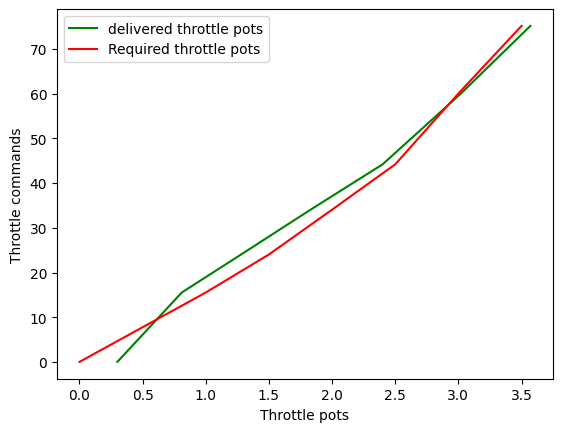

In [43]:
plt.plot(delivered_throttle_pots, delivered_throttle_cmds, label = 'delivered throttle pots', color = 'green')
plt.plot(requested_throttle_pots, delivered_throttle_cmds, label = 'Required throttle pots', color = 'red')
plt.xlabel('Throttle pots')
plt.ylabel('Throttle commands')
plt.legend()
plt.show()

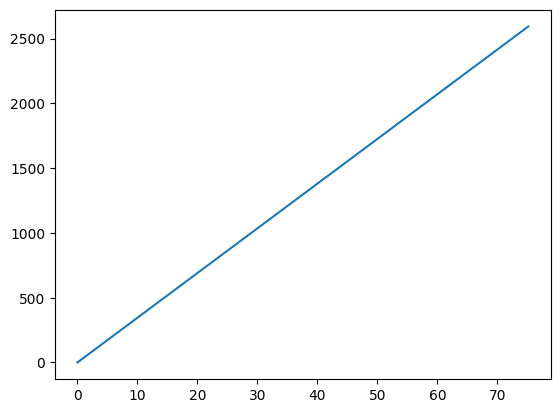

In [44]:
slope = (mean_saturation_motor_rpms[-2] - mean_saturation_motor_rpms[0]) / (delivered_throttle_cmds[-2] - delivered_throttle_cmds[0])
predicted_motor_rpms = [slope * delivered_throttle_cmds[i] for i in range(len(delivered_throttle_cmds))]
plt.plot(delivered_throttle_cmds, predicted_motor_rpms)
plt.show()

In [45]:
print(f'Throttle command for current max RPM of the vehicle is : {mean_saturation_motor_rpms[-1] / slope}')

Throttle command for current max RPM of the vehicle is : 65.6538397724694


In [46]:
slope_rpm_tcmd_file_path = os.path.join(internal_data_analysis_dir, 'slope_rpm_tcmd.pkl')
with open(slope_rpm_tcmd_file_path, 'wb') as f:
    pickle.dump([slope], f)

print(f'The slope of rpm vs tcmd has been stored at : {internal_data_analysis_dir}')

The slope of rpm vs tcmd has been stored at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis


In [47]:
store_rise_times = [0.0]
store_peak_rpms = [0.0]
for i in range(len(altered_data_list)):           # altered_data_list[i][3]             has the motor rpm data
    count = 0
    store_peak_rpms.append(max(altered_data_list[i][3]))
    for j in range(len(altered_data_list[i][3])):
        if altered_data_list[i][3][j] >= 0.1 * mean_saturation_motor_rpms[i + 1] and altered_data_list[i][3][j] <= 0.9 * mean_saturation_motor_rpms[i + 1]:
            count += 1
        elif altered_data_list[i][3][j] > 0.9 * mean_saturation_motor_rpms[i + 1]:
            break
    store_rise_times.append(round(count * 0.1, 2))

In [48]:
print(store_rise_times)
print(store_peak_rpms)

[0.0, 1.2, 1.0, 0.9, 2.3, 3.3, 4.3]
[0.0, 617, 950, 1293, 1599, 2110, 2350]


In [49]:
print(delivered_throttle_cmds)

[0.0, 15.52, 24.03, 34.05, 44.19, 60.02, 75.15]


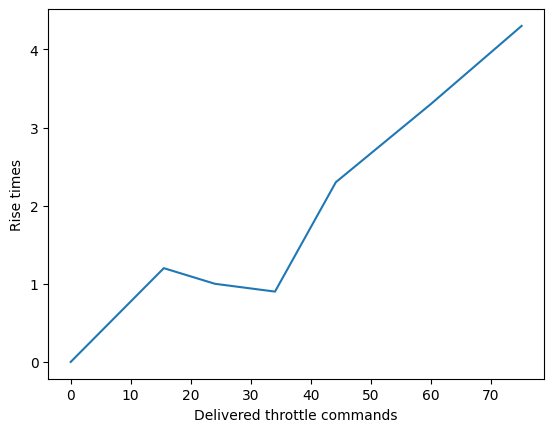

In [50]:
plt.plot(delivered_throttle_cmds, store_rise_times)
plt.xlabel('Delivered throttle commands')
plt.ylabel('Rise times')
plt.show()

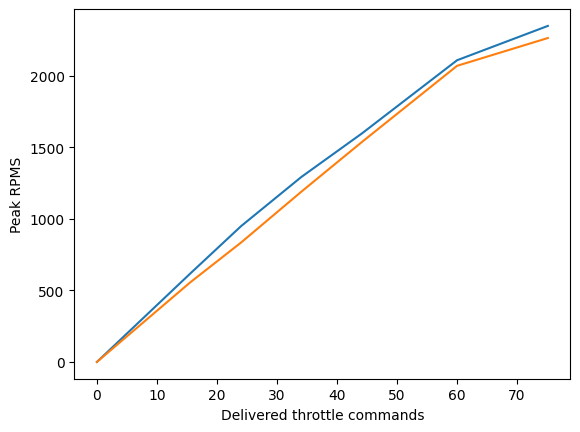

In [51]:
plt.plot(delivered_throttle_cmds, store_peak_rpms)
plt.plot(delivered_throttle_cmds, mean_saturation_motor_rpms)
plt.xlabel('Delivered throttle commands')
plt.ylabel('Peak RPMS')
plt.show()

In [52]:
print(f'Throttle pots requested : {requested_throttle_pots}')
print(f'Throttle pots delivered : {delivered_throttle_pots}')
print(f'Throttle commands delivered : {delivered_throttle_cmds}')
print(f'Resulted motor rpms : {mean_saturation_motor_rpms}')

Throttle pots requested : [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
Throttle pots delivered : [0.3, 0.81, 1.28, 1.83, 2.4, 3.02, 3.57]
Throttle commands delivered : [0.0, 15.52, 24.03, 34.05, 44.19, 60.02, 75.15]
Resulted motor rpms : [0.0, 555.5, 835.38, 1190.0, 1539.28, 2070.93, 2265.32]


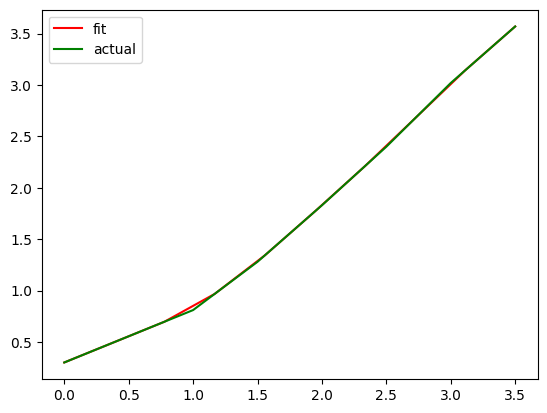

In [53]:
Rbf_interp = Rbf(requested_throttle_pots, delivered_throttle_pots, function = 'linear') 
new_requested_throttle_pots = np.linspace(requested_throttle_pots[0], requested_throttle_pots[-1], 10)
new_delivered_throttle_pots = Rbf_interp(new_requested_throttle_pots)
plt.plot(new_requested_throttle_pots, new_delivered_throttle_pots, label = 'fit', color = 'red')
plt.plot(requested_throttle_pots, delivered_throttle_pots, label = 'actual', color = 'green')
plt.legend()
plt.show()

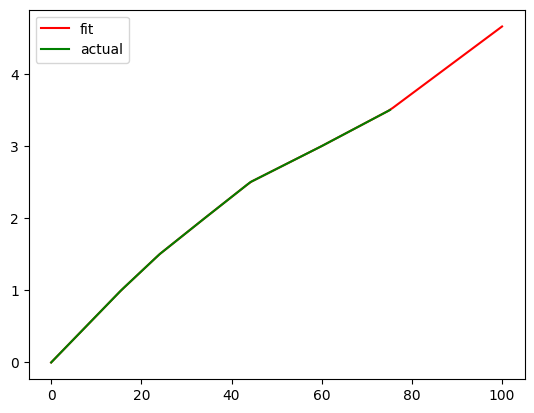

In [54]:
Rbf_interp = Rbf(delivered_throttle_cmds, requested_throttle_pots, function = 'linear') 
new_delivered_throttle_cmds = np.linspace(0, 100, 100)
new_requested_throttle_pots = Rbf_interp(new_delivered_throttle_cmds)
plt.plot(new_delivered_throttle_cmds, new_requested_throttle_pots, label = 'fit', color = 'red')
plt.plot(delivered_throttle_cmds, requested_throttle_pots, label = 'actual', color = 'green')
plt.legend()
plt.show()

In [55]:
print(Rbf_interp(np.array([47.6])))

[2.60770689]


In [56]:
file_path = os.path.join(internal_data_analysis_dir, 'rbf_model_tcmd_to_requested_pot.pkl')
Rbf_data = {
    'x' : delivered_throttle_cmds,
    'y' : requested_throttle_pots,
    'function' : 'linear'
}
with open(file_path, 'wb') as f:
    pickle.dump(Rbf_data, f)

print(f"RBF Interpolator saved at : {file_path}")

RBF Interpolator saved at : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\2_Data_Analysis\rbf_model_tcmd_to_requested_pot.pkl
